In [72]:
# Required Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_style("whitegrid")

In [73]:
# Dataset load karna
df = pd.read_csv('student_habits_performance.csv')

# Dataset ki pehli 5 rows dekhna
df.head()

,student_id,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,S1000,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,S1001,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,S1002,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,S1003,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,S1004,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [74]:
target_col = 'exam_score'

X = df.drop(target_col, axis=1) # Features
y = df[target_col] # Target

print("Features:", X.shape[1], "columns")

Features: 15 columns


In [75]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [76]:
# Target Column: exam_score - chotay e se
target_col = 'exam_score'

X = df.drop(target_col, axis=1)  # Features
y = df[target_col]               # Target

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 15)
Target Shape: (1000,)


In [77]:
# 80% Training, 20% Testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (800, 15)
Testing Data: (200, 15)


In [78]:
import pandas as pd
import numpy as np

df = pd.read_csv('student_habits_performance.csv')

# 1. student_id hatao
df = df.drop('student_id', axis=1, errors='ignore')

# 2. Sab text ko number banao
df = pd.get_dummies(df, drop_first=True)

# 3. CHECK KARO: koi string column to nahi bacha?
print("Data Types:\n", df.dtypes)
print("\nAgar yahan 'object' likha aya to masla hai")

Data Types:
 age                                       int64
study_hours_per_day                     float64
social_media_hours                      float64
netflix_hours                           float64
attendance_percentage                   float64
sleep_hours                             float64
exercise_frequency                        int64
mental_health_rating                      int64
exam_score                              float64
gender_Male                                bool
gender_Other                               bool
part_time_job_Yes                          bool
diet_quality_Good                          bool
diet_quality_Poor                          bool
parental_education_level_High School       bool
parental_education_level_Master            bool
internet_quality_Good                      bool
internet_quality_Poor                      bool
extracurricular_participation_Yes          bool
dtype: object

Agar yahan 'object' likha aya to masla hai


In [79]:
from sklearn.model_selection import train_test_split

target_col = 'exam_score'

X = df.drop(target_col, axis=1)
y = df[target_col]

# Double check: X me string hai kya?
print("X me koi string hai?", X.select_dtypes(include='object').columns.tolist())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X me koi string hai? []


In [80]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train) # ab error nahi aayega

y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
print("Model Training Complete ")
print("R2 Score:", round(r2, 4))

Model Training Complete 
R2 Score: 0.8968


In [81]:
# Test data par prediction
y_pred = model.predict(X_test)

# Pehle 10 Actual vs Predicted
results = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
results.head(10)

,Actual,Predicted
521,64.2,66.298252
737,72.7,75.159355
740,79.0,78.382447
660,79.5,73.428602
411,58.2,61.147003
678,53.4,54.042756
626,70.8,75.413251
513,62.5,55.139735
859,36.8,40.757524
136,67.6,72.237489


In [82]:
# Evaluation Metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R² Score : {r2:.4f}")

Model Performance:
MAE  : 4.18
MSE  : 26.46
RMSE : 5.14
R² Score : 0.8968


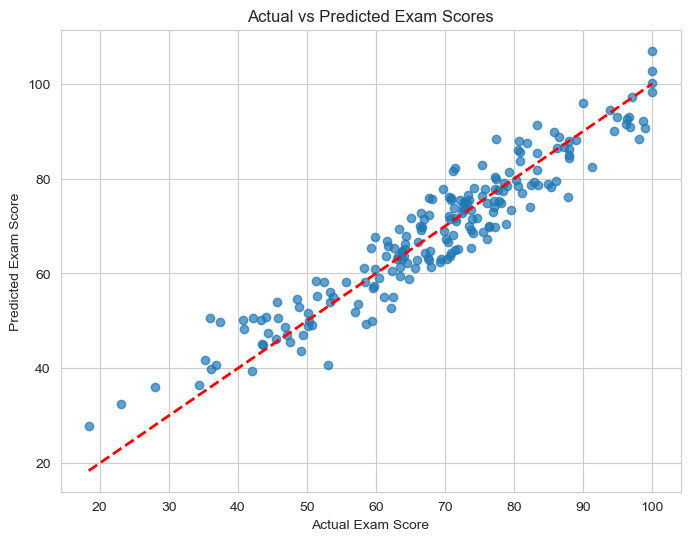

Conclusion: Model ka R² score 0.9 hai


In [83]:
# Graph
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Perfect line
plt.xlabel("Actual Exam Score")
plt.ylabel("Predicted Exam Score")
plt.title("Actual vs Predicted Exam Scores")
plt.show()

print("Conclusion: Model ka R² score", round(r2,2), "hai")